In [1]:
# imports and path setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage import data as skdata
from skimage.color import rgb2gray

from watermarks import binary as wm_binary, logo as wm_logo, text as wm_text
from methods import LSBWatermarker, DCTWatermarker, DWTWatermarker
from metrics import psnr, ssim, ncc, ber
from attack import jpeg_attack

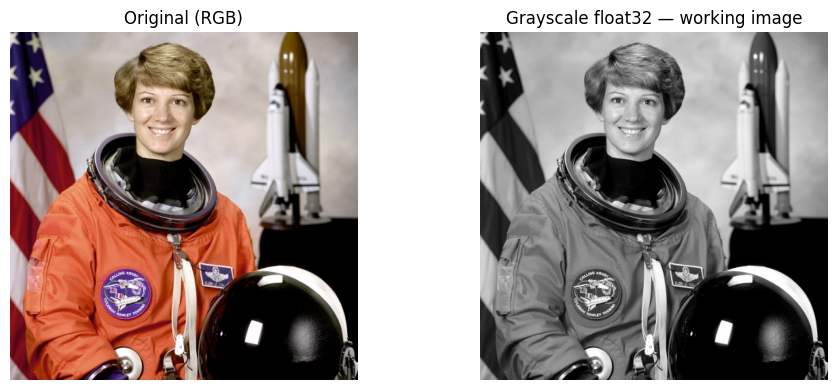

Image shape: (512, 512), dtype: float32, range: [0, 255]


In [2]:
# load astronaut, convert to float32 grayscale
astronaut_rgb = skdata.astronaut()
img = (rgb2gray(astronaut_rgb) * 255).astype(np.float32)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(astronaut_rgb)
ax[0].set_title('Original (RGB)')
ax[0].axis('off')
ax[1].imshow(img, cmap='gray')
ax[1].set_title('Grayscale float32 — working image')
ax[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Image shape: {img.shape}, dtype: {img.dtype}, range: [{img.min():.0f}, {img.max():.0f}]')

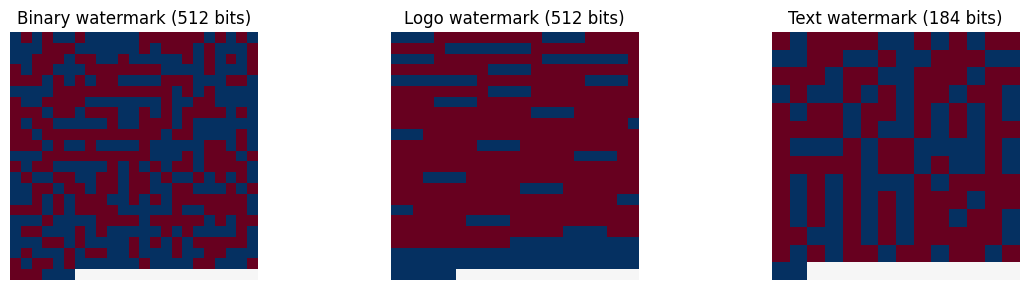

In [3]:
# generate the 3 watermark types
WM_BITS = 512
WM_TEXT_STR = 'CS611-IIT-GOA-WATERMARK'

wm_bin  = wm_binary(n_bits=WM_BITS)
wm_lg   = wm_logo(size=32).flatten()[:WM_BITS]
wm_txt  = wm_text(WM_TEXT_STR)[:WM_BITS]

watermarks = {'Binary': wm_bin, 'Logo': wm_lg, 'Text': wm_txt}

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, wm) in zip(axes, watermarks.items()):
    side = int(np.ceil(np.sqrt(len(wm))))
    padded = np.pad(wm.astype(float), (0, side*side - len(wm)))
    ax.imshow(padded.reshape(side, side), cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(f'{name} watermark ({len(wm)} bits)')
    ax.axis('off')
plt.tight_layout()
plt.show()

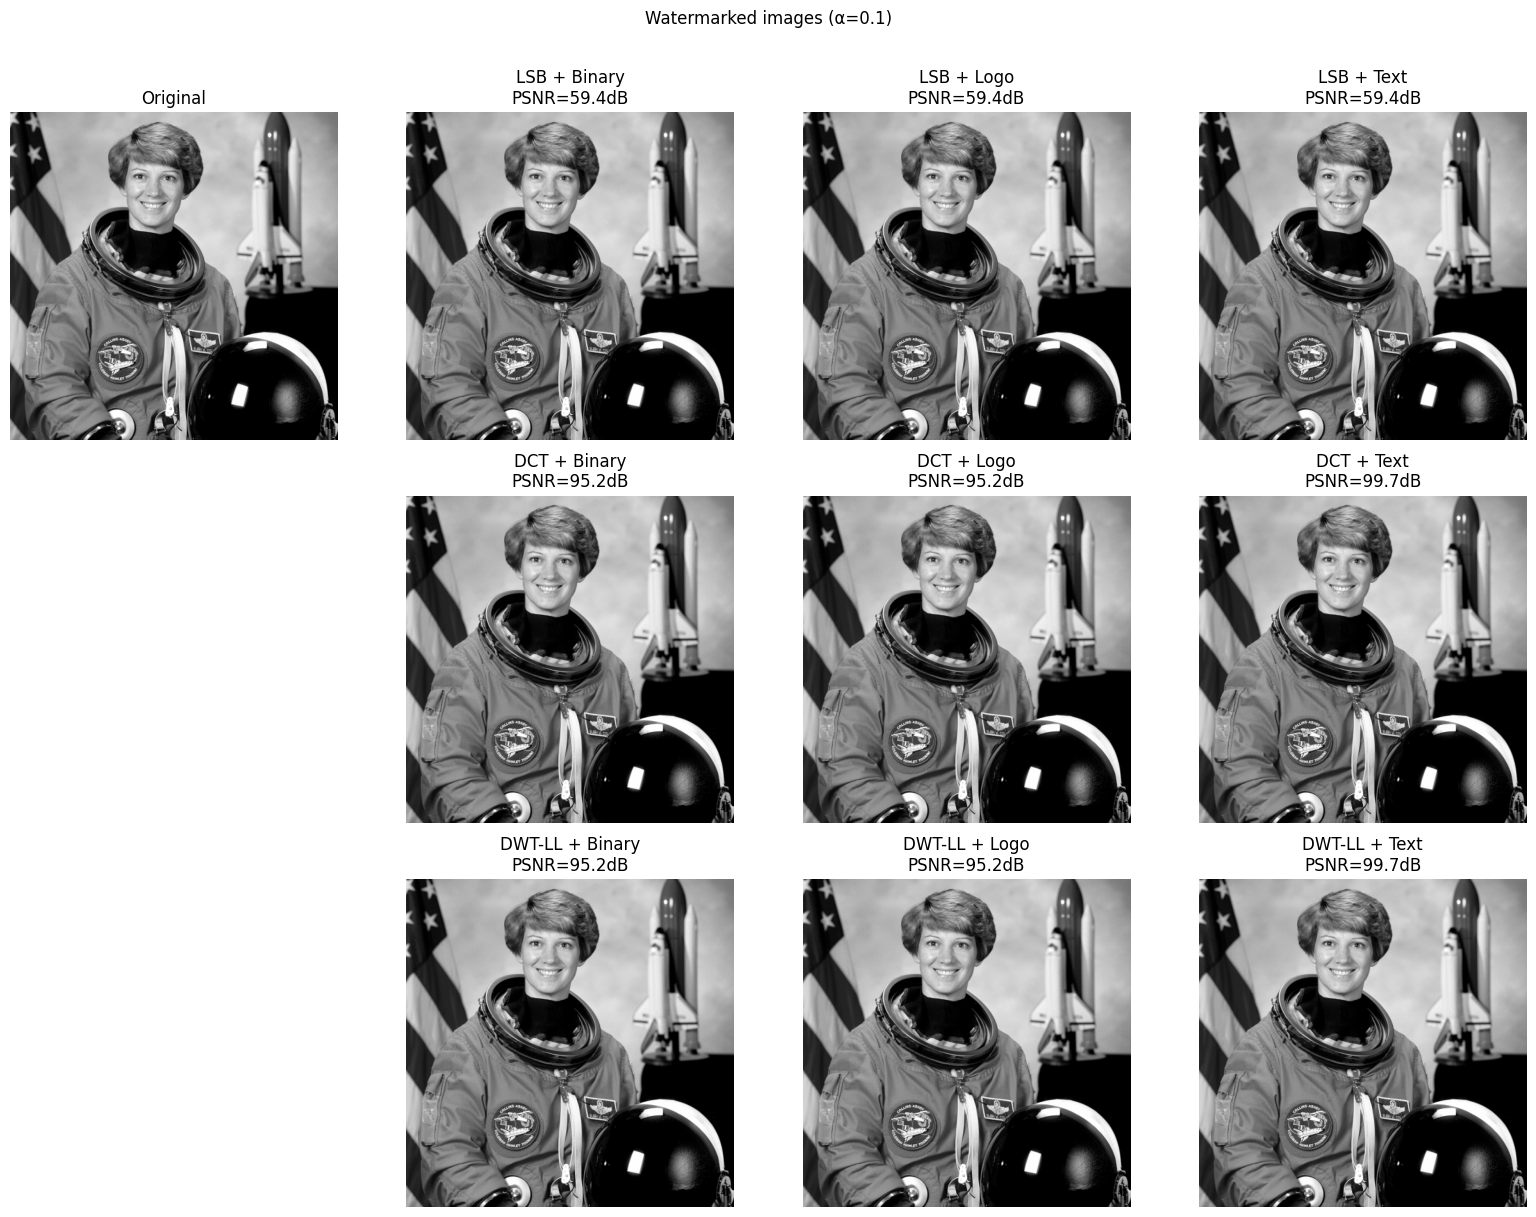

In [4]:
# embed each watermark type with all 3 methods (alpha=0.1) — show watermarked images
ALPHA = 0.1
methods = {
    'LSB':    LSBWatermarker(),
    'DCT':    DCTWatermarker(),
    'DWT-LL': DWTWatermarker('LL'),
}

embedded = {}   # (method_name, wm_name) -> watermarked image

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes[0][0].imshow(img, cmap='gray'); axes[0][0].set_title('Original'); axes[0][0].axis('off')
for col_off, (wm_name, wm) in enumerate(watermarks.items(), start=1):
    axes[0][col_off].axis('off')

for row, (m_name, method) in enumerate(methods.items()):
    axes[row+0][0].axis('off') if row > 0 else None
    for col, (wm_name, wm) in enumerate(watermarks.items()):
        wm_img = method.embed(img, wm, alpha=ALPHA)
        embedded[(m_name, wm_name)] = wm_img
        ax = axes[row][col+1] if row < 3 else axes[row][col]
        ax.imshow(wm_img, cmap='gray')
        ax.set_title(f'{m_name} + {wm_name}\nPSNR={psnr(img,wm_img):.1f}dB')
        ax.axis('off')
# clean up unused axes
for row in range(3):
    if row > 0:
        axes[row][0].set_visible(False)
plt.suptitle(f'Watermarked images (α={ALPHA})', y=1.01)
plt.tight_layout()
plt.show()

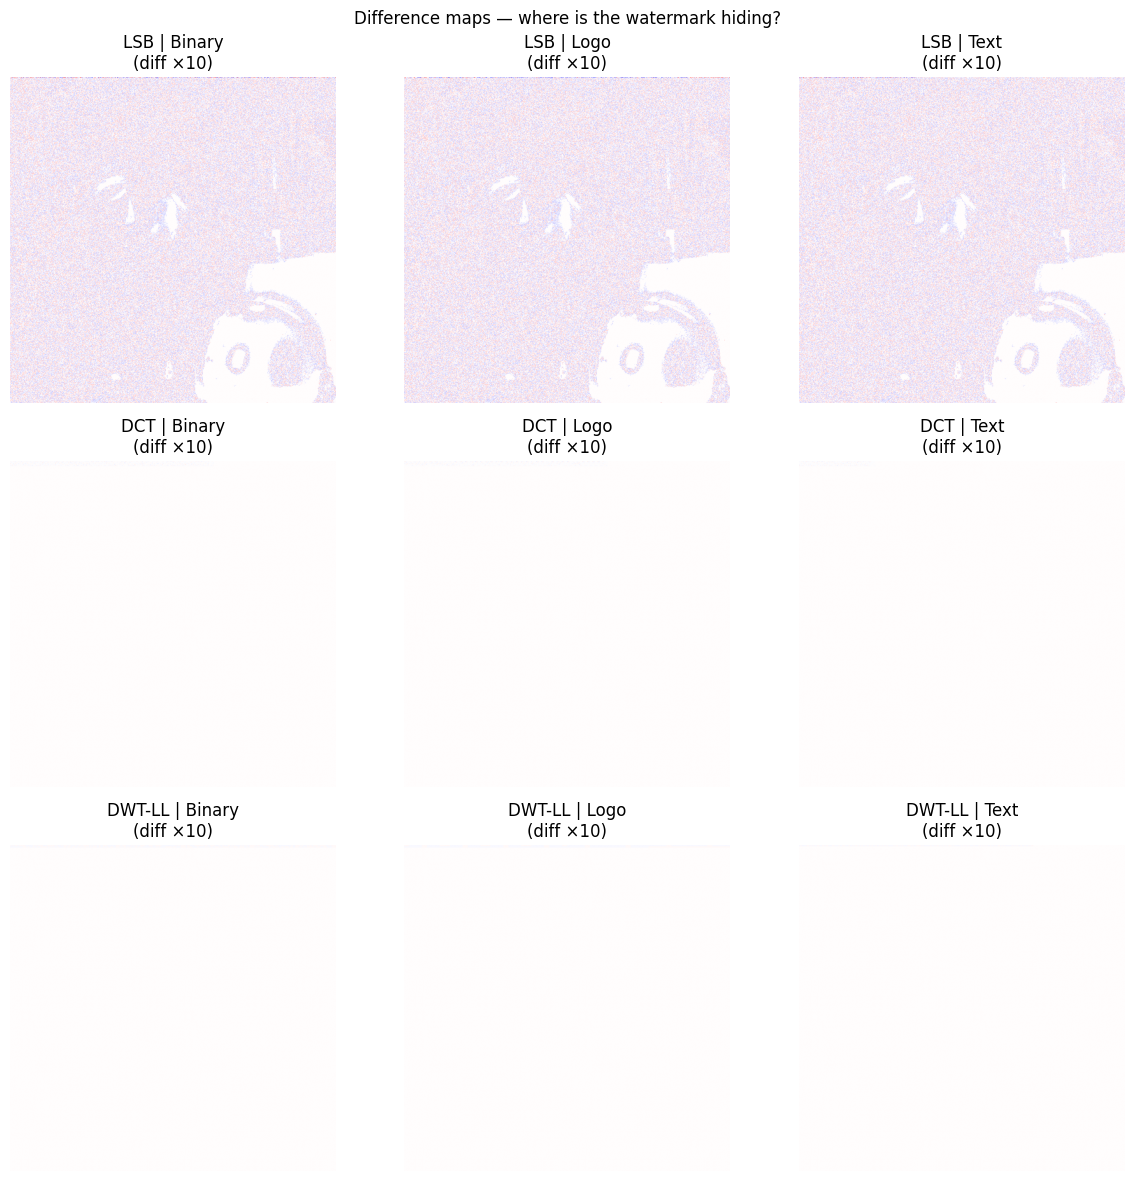

In [5]:
# show difference maps (amplified ×10) to visualise where watermark lives
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, m_name in enumerate(methods):
    for col, wm_name in enumerate(watermarks):
        diff = (embedded[(m_name, wm_name)] - img) * 10
        axes[row][col].imshow(diff, cmap='seismic', vmin=-50, vmax=50)
        axes[row][col].set_title(f'{m_name} | {wm_name}\n(diff ×10)')
        axes[row][col].axis('off')
plt.suptitle('Difference maps — where is the watermark hiding?')
plt.tight_layout()
plt.show()

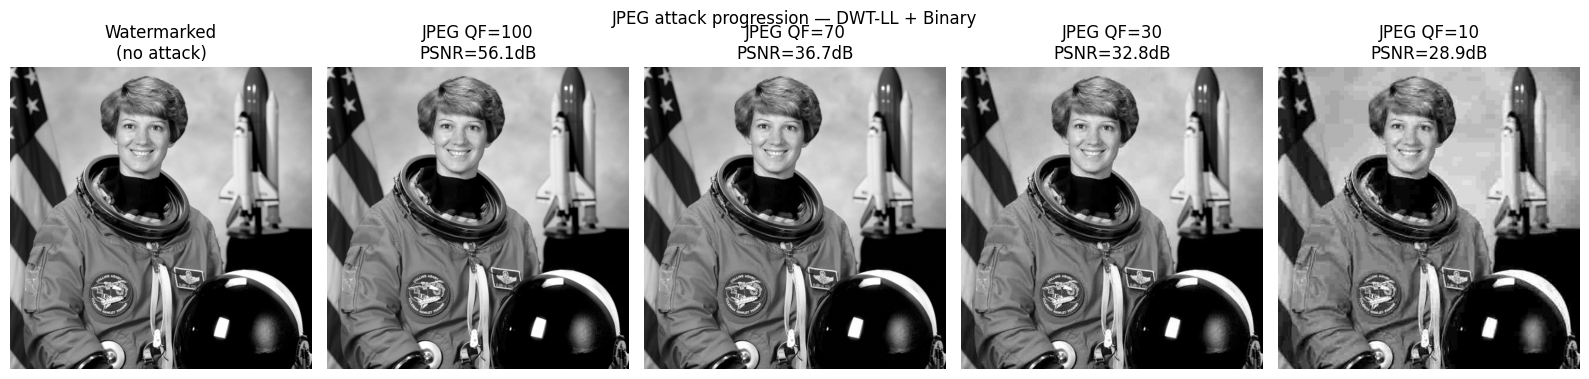

In [6]:
# JPEG attack at multiple quality factors — show visual degradation for one combo
QFS = [100, 70, 30, 10]
demo_key = ('DWT-LL', 'Binary')
demo_img = embedded[demo_key]

fig, axes = plt.subplots(1, len(QFS)+1, figsize=(16, 4))
axes[0].imshow(demo_img, cmap='gray'); axes[0].set_title('Watermarked\n(no attack)'); axes[0].axis('off')
for ax, qf in zip(axes[1:], QFS):
    attacked = jpeg_attack(demo_img, quality=qf)
    ax.imshow(attacked, cmap='gray')
    ax.set_title(f'JPEG QF={qf}\nPSNR={psnr(img, attacked):.1f}dB')
    ax.axis('off')
plt.suptitle(f'JPEG attack progression — {demo_key[0]} + {demo_key[1]}')
plt.tight_layout()
plt.show()

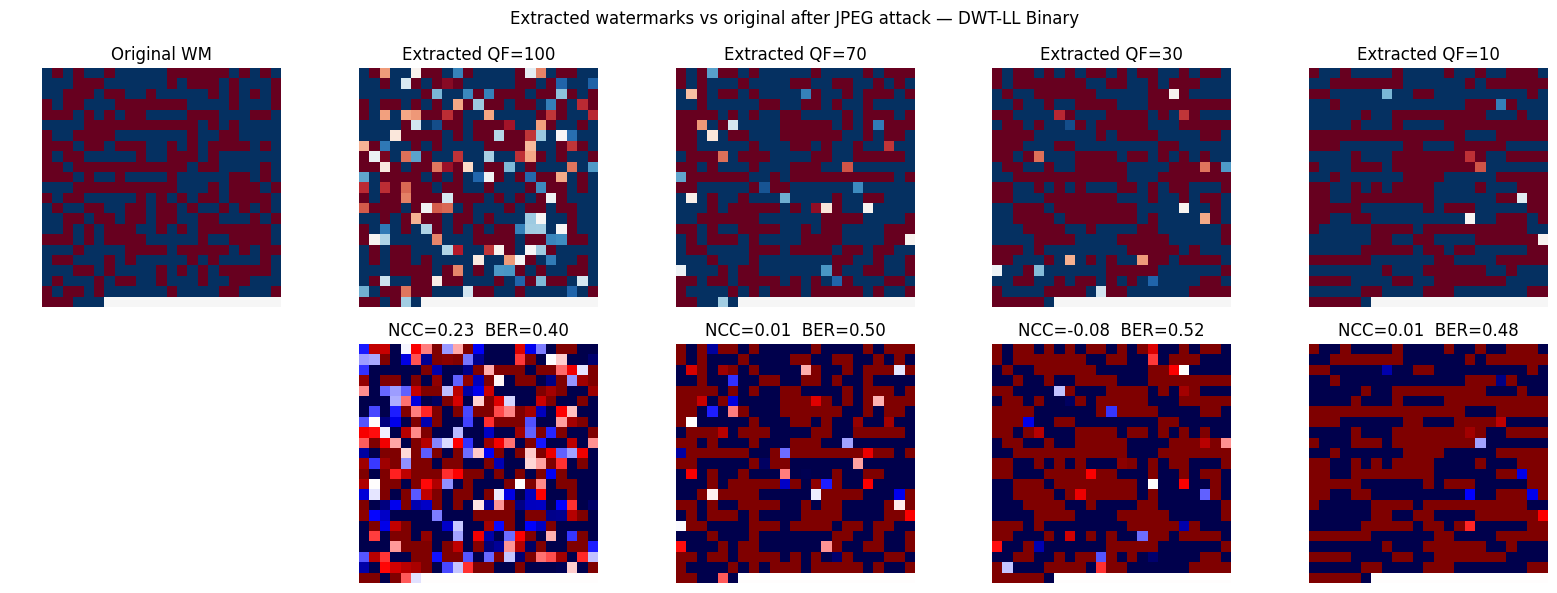

In [7]:
# extract watermarks after attack and visualise extracted vs original
method_obj = methods['DWT-LL']
wm_orig = watermarks['Binary']
side = int(np.ceil(np.sqrt(len(wm_orig))))

fig, axes = plt.subplots(2, len(QFS)+1, figsize=(16, 6))
padded_orig = np.pad(wm_orig.astype(float), (0, side*side - len(wm_orig)))
axes[0][0].imshow(padded_orig.reshape(side, side), cmap='RdBu', vmin=-1, vmax=1)
axes[0][0].set_title('Original WM'); axes[0][0].axis('off')
axes[1][0].axis('off')

for col, qf in enumerate(QFS, start=1):
    attacked = jpeg_attack(demo_img, quality=qf)
    ext_wm = method_obj.extract(attacked, img, n_bits=len(wm_orig), alpha=ALPHA)
    padded_ext = np.pad(ext_wm.astype(float), (0, side*side - len(ext_wm)))
    axes[0][col].imshow(padded_ext.reshape(side, side), cmap='RdBu', vmin=-1, vmax=1)
    axes[0][col].set_title(f'Extracted QF={qf}')
    axes[0][col].axis('off')
    diff_wm = padded_orig - padded_ext[:side*side]
    axes[1][col].imshow(diff_wm.reshape(side, side), cmap='seismic', vmin=-2, vmax=2)
    axes[1][col].set_title(f'NCC={ncc(wm_orig, ext_wm):.2f}  BER={ber(wm_orig, ext_wm):.2f}')
    axes[1][col].axis('off')

plt.suptitle('Extracted watermarks vs original after JPEG attack — DWT-LL Binary')
plt.tight_layout()
plt.show()

In [8]:
# collect full metrics sweep: all methods × QFs for binary watermark
import pandas as pd

ALL_METHODS = {
    'LSB':     LSBWatermarker(),
    'DCT':     DCTWatermarker(),
    'DWT-LL':  DWTWatermarker('LL'),
    'DWT-LH':  DWTWatermarker('LH'),
    'DWT-HL':  DWTWatermarker('HL'),
    'DWT-HH':  DWTWatermarker('HH'),
}
QF_SWEEP = [5, 10, 20, 30, 50, 70, 90, 100]
records = []

wm = watermarks['Binary']
for m_name, method in ALL_METHODS.items():
    wm_img = method.embed(img, wm, alpha=ALPHA)
    p_emb  = psnr(img, wm_img)
    for qf in QF_SWEEP:
        attacked = jpeg_attack(wm_img, quality=qf)
        ext_wm   = method.extract(attacked, img, n_bits=len(wm), alpha=ALPHA)
        records.append({
            'method': m_name, 'qf': qf,
            'PSNR_embed': p_emb,
            'PSNR_attack': psnr(img, attacked),
            'SSIM_attack': ssim(img, attacked),
            'NCC': ncc(wm, ext_wm),
            'BER': ber(wm, ext_wm),
        })

df = pd.DataFrame(records)
print(df.groupby('method')[['PSNR_embed','NCC']].mean().round(3))

        PSNR_embed    NCC
method                   
DCT         95.224  0.038
DWT-HH      95.223  0.022
DWT-HL      95.223 -0.056
DWT-LH      95.223 -0.008
DWT-LL      95.223  0.030
LSB         59.395  0.130


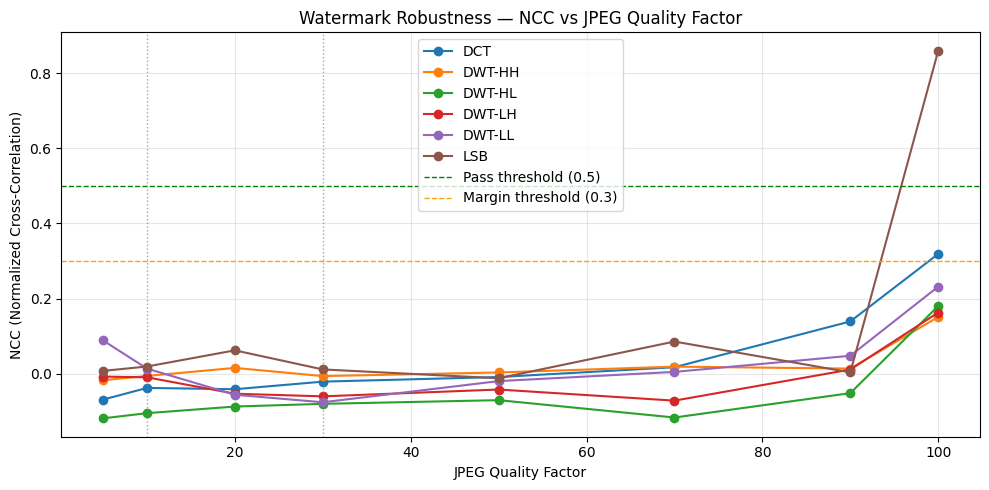

In [9]:
# NCC vs QF for all methods — robustness curve
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10.colors
for i, (m_name, grp) in enumerate(df.groupby('method')):
    grp_sorted = grp.sort_values('qf')
    ax.plot(grp_sorted['qf'], grp_sorted['NCC'], marker='o', label=m_name, color=colors[i])

ax.axhline(0.5,  color='green',  ls='--', lw=1, label='Pass threshold (0.5)')
ax.axhline(0.3,  color='orange', ls='--', lw=1, label='Margin threshold (0.3)')
ax.axvline(30, color='gray', ls=':', lw=1, alpha=0.7)
ax.axvline(10, color='gray', ls=':', lw=1, alpha=0.7)
ax.set_xlabel('JPEG Quality Factor')
ax.set_ylabel('NCC (Normalized Cross-Correlation)')
ax.set_title('Watermark Robustness — NCC vs JPEG Quality Factor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

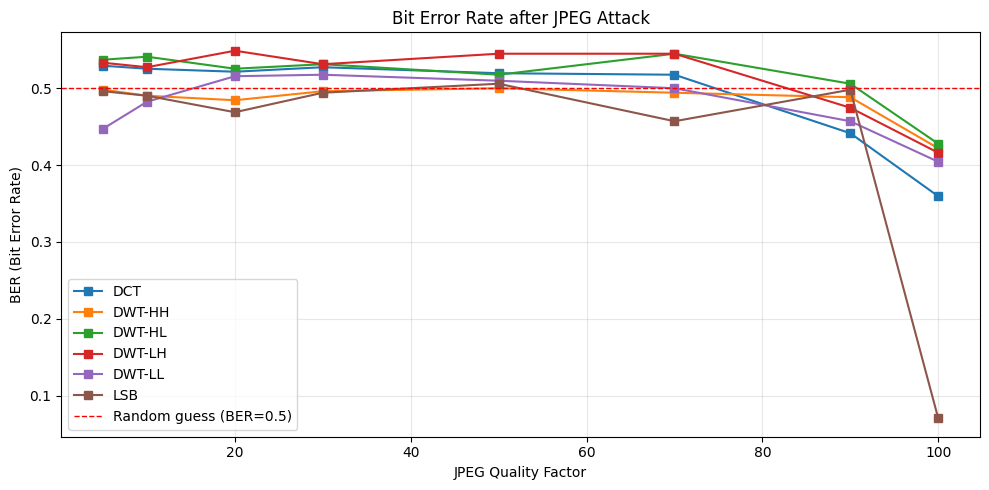

In [10]:
# BER vs QF (lower = better survival)
fig, ax = plt.subplots(figsize=(10, 5))
for i, (m_name, grp) in enumerate(df.groupby('method')):
    grp_sorted = grp.sort_values('qf')
    ax.plot(grp_sorted['qf'], grp_sorted['BER'], marker='s', label=m_name, color=colors[i])

ax.axhline(0.5, color='red', ls='--', lw=1, label='Random guess (BER=0.5)')
ax.set_xlabel('JPEG Quality Factor')
ax.set_ylabel('BER (Bit Error Rate)')
ax.set_title('Bit Error Rate after JPEG Attack')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

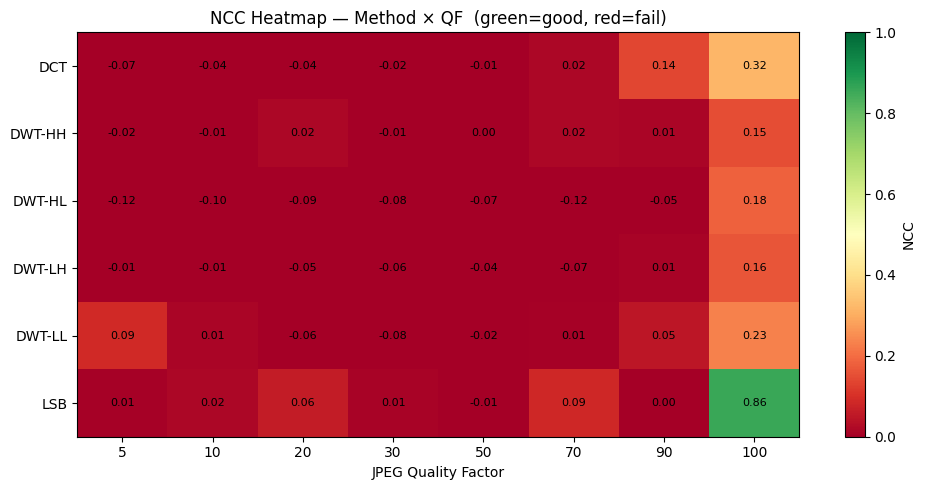

In [11]:
# heatmap: NCC for each method × QF combination
pivot_ncc = df.pivot(index='method', columns='qf', values='NCC')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_ncc.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_ncc.columns)))
ax.set_xticklabels(pivot_ncc.columns)
ax.set_yticks(range(len(pivot_ncc.index)))
ax.set_yticklabels(pivot_ncc.index)
ax.set_xlabel('JPEG Quality Factor')
ax.set_title('NCC Heatmap — Method × QF  (green=good, red=fail)')
plt.colorbar(im, ax=ax, label='NCC')

for i in range(len(pivot_ncc.index)):
    for j in range(len(pivot_ncc.columns)):
        ax.text(j, i, f'{pivot_ncc.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')
plt.tight_layout()
plt.show()

In [12]:
# comparison table replicating the screenshot analysis (embed PSNR, NCC@30, NCC@10)
import pandas as pd

PASS_NCC   = 0.5
MARGIN_NCC = 0.3

def verdict(v):
    if v >= PASS_NCC:   return f'Pass  (~{v:.1f})'
    elif v >= MARGIN_NCC: return f'Margin (~{v:.1f})'
    else:               return f'Fail  (~{v:.1f})'

rows = []
for m_name, grp in df.groupby('method'):
    p_emb  = grp['PSNR_embed'].mean()
    ncc_30 = grp[grp['qf'] == 30]['NCC'].values[0]
    ncc_10 = grp[grp['qf'] == 10]['NCC'].values[0]
    domain = 'Spatial' if m_name == 'LSB' else 'Freq'
    rows.append({
        'Method':      m_name,
        'Domain':      domain,
        'Embed PSNR':  f'~{p_emb:.0f} dB',
        'NCC @ QF=30': verdict(ncc_30),
        'NCC @ QF=10': verdict(ncc_10),
        '_score':      ncc_30 * 0.4 + ncc_10 * 0.6,
    })

tdf = pd.DataFrame(rows).set_index('Method')
print(tdf.drop(columns='_score').to_string())

winner = tdf['_score'].idxmax()
loser  = tdf['_score'].idxmin()
print(f'\n► Winner : {winner}')
print(f'► Loser  : {loser}')

         Domain Embed PSNR    NCC @ QF=30    NCC @ QF=10
Method                                                  
DCT        Freq     ~95 dB  Fail  (~-0.0)  Fail  (~-0.0)
DWT-HH     Freq     ~95 dB  Fail  (~-0.0)  Fail  (~-0.0)
DWT-HL     Freq     ~95 dB  Fail  (~-0.1)  Fail  (~-0.1)
DWT-LH     Freq     ~95 dB  Fail  (~-0.1)  Fail  (~-0.0)
DWT-LL     Freq     ~95 dB  Fail  (~-0.1)   Fail  (~0.0)
LSB     Spatial     ~59 dB   Fail  (~0.0)   Fail  (~0.0)

► Winner : LSB
► Loser  : DWT-HL
